# How to create highlights in the images.

In [ ]:
from pathlib import Path
from ultralytics import YOLO
from scanner_api.app_models import Scanner, OrderModel # necessary imports.
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

## Model loading

The `Scanner` model is a pipeline composed by two models: `YOLO` and `OrderModel`, so to use it, we have to load our `YOLO` and `OrderModel` models, then we give those models to our `Scanner` object when creating an instance.

The `YOLO` model is loaded by giving the path to a yolo model file to the `YOLO` constructor, the `OrderModel` is loaded by giving it the path to .csv file that contains the data of a base shelf in the yolo format (columns being class, x, y, w, h).

And that's it, we are ready to use it!

In [3]:
model_path = Path.cwd().parent/'models'/'my_model.pt'
shelf_path = Path.cwd().parent/'src'/'scanner_api'/'shelves'/'BATERIAS (1F) 0,36M.csv'
test_img = Path.cwd().parent/'data'/'test'/'test_img.jpeg'

yolo_model = YOLO(model_path)
order_model = OrderModel(shelf_path)

scanner = Scanner(yolo_model=yolo_model, order_model=order_model)
pred = scanner.predict(test_img)


image 1/1 c:\Users\shade\OneDrive\Documentos\Coding Projects\4geeks projects\shelf-scanner\data\test\test_img.jpeg: 640x384 1 Bateria Duracell AA 2Und, 1 Bateria Duracell AAA 2Und, 1 Bateria Energizer A23 2Und, 1 Bateria Energizer Max 9V, 2 Bateria Energizer Max AA 2Unds, 2 Bateria Energizer Max AA 4 Unds, 2 Bateria Energizer Max AAA 2 Unds, 2 Bateria Energizer Max AAA 4 Unds, 1 Bateria Energizer Max C 2 Und, 1 Bateria Energizer Max D Alkalina 2 Und, 1 Bateria Kodak 9V EHD, 2 Bateria Philips Boton Litio 2032 X5s, 4 Bateria Philips Power Alkaline AA 2Unds, 3 Bateria Philips Power Alkaline AAA 2Unds, 1 Linterna Rayovac Recargable Mini 5 Led, 460.1ms
Speed: 14.3ms preprocess, 460.1ms inference, 47.6ms postprocess per image at shape (1, 3, 640, 384)


C:\Users\shade\AppData\Local\Temp\ipykernel_12084\2806724914.py:41: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  box = Rectangle(


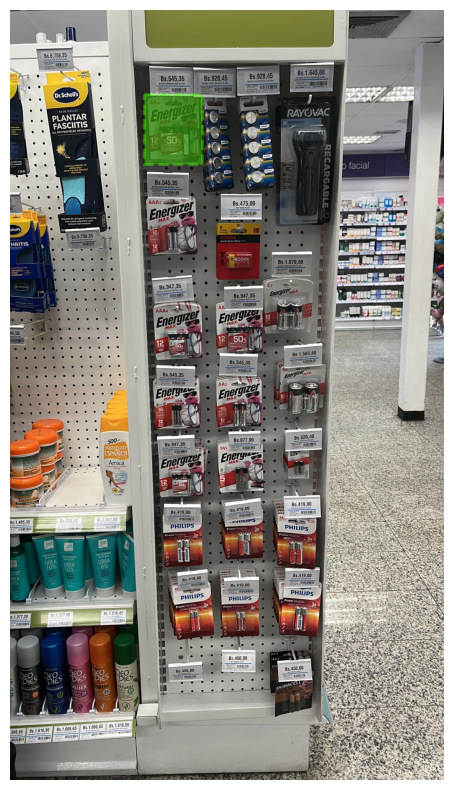

In [6]:
df = pred.order_result[1].iloc[0]



# --- Configuration for the box ---
# Center coordinates of the box
CENTER_X = df['x']
CENTER_Y = df['y']


# Dimensions of the box
WIDTH = df['h']
HEIGHT = df['w']

# Translucency level (alpha)
# 0.0 is fully transparent, 1.0 is fully opaque. 0.3 is 'somewhat translucent'
ALPHA_LEVEL = 0.4

# Color of the box
BOX_COLOR = '#4CFE05'

def draw_translucent_box(ax, center_x, center_y, width, height, color, alpha):
    """
    Calculates the bottom-left coordinates and adds a Rectangle patch to the Axes.

    Args:
        ax (matplotlib.axes.Axes): The axes object to draw the patch on.
        center_x (float): X-coordinate of the box center.
        center_y (float): Y-coordinate of the box center.
        width (float): Width of the box.
        height (float): Height of the box.
        color (str): Color of the box.
        alpha (float): Translucency level (0.0 to 1.0).
    """
    # 1. Calculate the bottom-left corner (x, y)
    # This is the starting point required by the Rectangle patch constructor.
    x_bottom_left = center_x - width / 2
    y_bottom_left = center_y - height / 2

    # 2. Create the Rectangle patch
    box = Rectangle(
        (x_bottom_left, y_bottom_left), # Bottom-left (x, y)
        width,                          # Width
        height,                         # Height
        color=color,                    # Fill color
        alpha=alpha,                    # Translucency
        fill=True,                      # Ensure the area is filled
        # Optional: set the edge color and style
        edgecolor=color,
        linestyle='--',
        linewidth=2
    )

    # 3. Add the patch to the Axes
    ax.add_patch(box)
    
    # Return the patch object if further manipulation is needed
    return box

# --- Main Plotting Setup ---
fig, ax = plt.subplots(figsize=(10, 10))



# 2. Draw the translucent box
highlight_box = draw_translucent_box(
    ax, 
    CENTER_X, 
    CENTER_Y, 
    WIDTH, 
    HEIGHT, 
    BOX_COLOR, 
    ALPHA_LEVEL
)

# 3. Final plot settings
img = Image.open(test_img)
ax.imshow(img)
ax.axis('off')
plt.show()

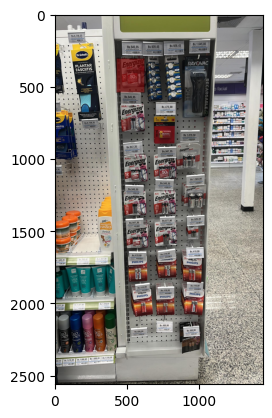

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots()

x_start = df['x']
y_start = df['y']
width = df['w']
height = df['h']

# Create the Rectangle patch
# facecolor='red' sets the color of the box
# alpha=0.3 makes it highly translucent
rect = patches.Rectangle((x_start-width/2, y_start-height/2),
                         height,
                         width,
                         linewidth=1,
                         edgecolor='black', # Border color
                         facecolor='red',
                         alpha=0.3,
                         label='Custom Box')

# Add the rectangle to the plot
ax.add_patch(rect)

# Set plot limits (important for seeing the rectangle)
ax.set_aspect('equal') # Optional: Makes the scaling equal
ax.imshow(img)


plt.show()